<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>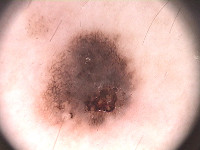</td><td>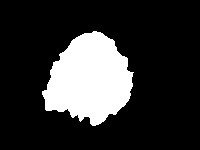</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

In [2]:
# get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
import torch
import random
import numpy as np
seed = 12345

# General PyTorch seed (affects both CPU and CUDA)
torch.manual_seed(seed)

# CUDA specific seeds
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed) # For multi-GPU

# CuDNN determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# External libraries
random.seed(seed)
np.random.seed(seed)

In [4]:
images = []
lesions = []
from skimage.io import imread
import os
root = '../images/PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [5]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [6]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

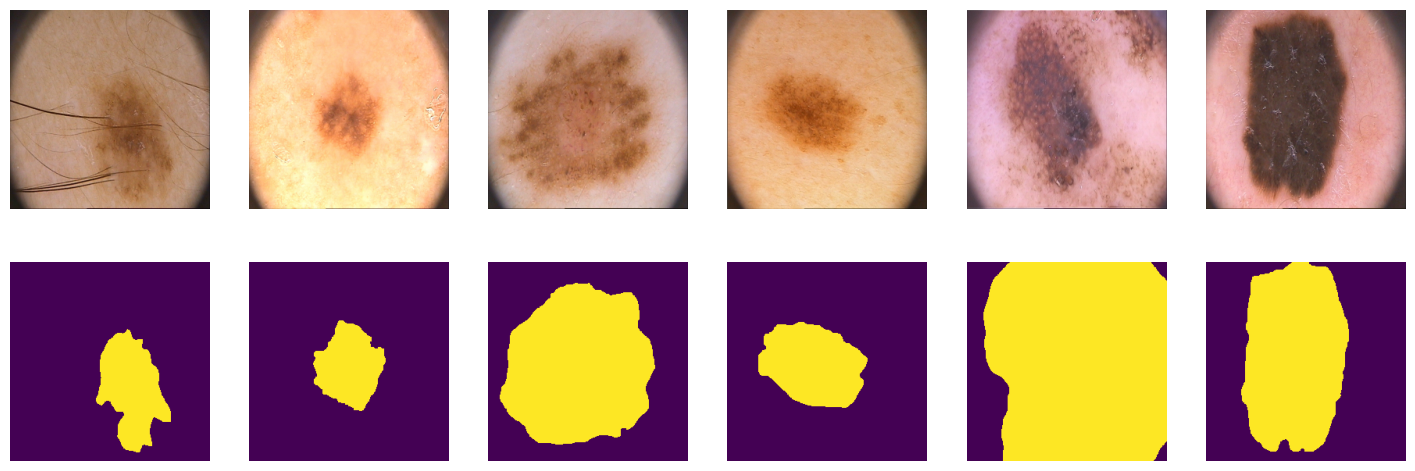

In [7]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [8]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [9]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [10]:
from torch.utils.data import DataLoader
batch_size = 4
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=2, shuffle=False)

In [11]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [12]:
# !pip install torchmetrics

In [13]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

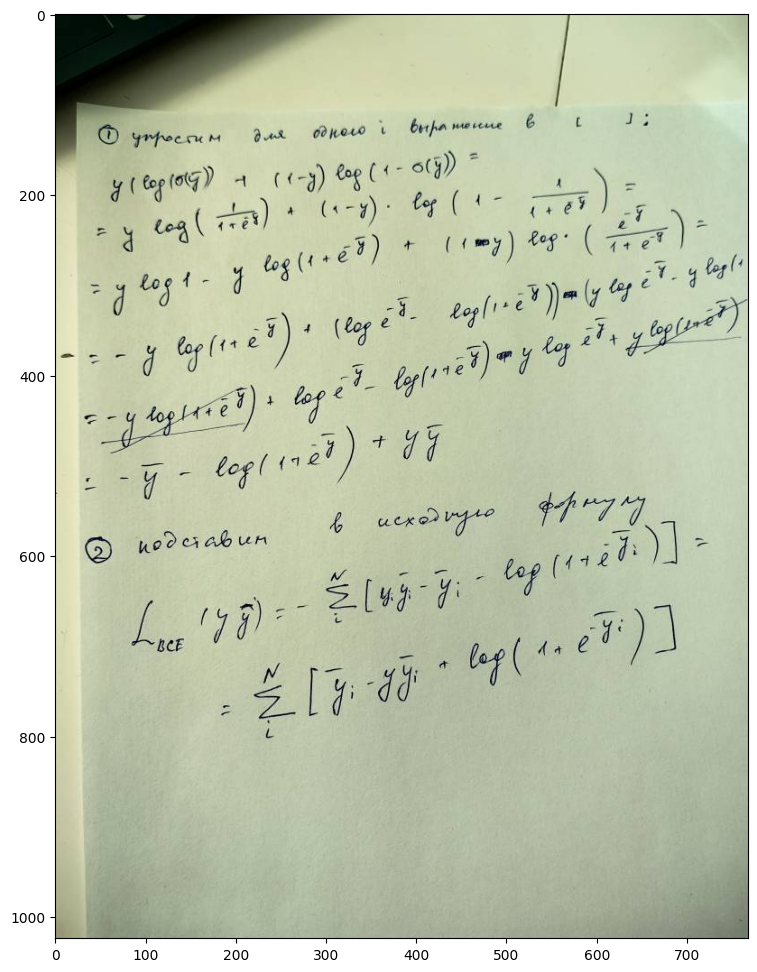

In [14]:
from PIL import Image
PATH = 'loss.jpg'
loss = Image.open(PATH)
plt.figure(figsize=(12, 12))
plt.imshow(loss)

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [15]:
import torch.nn.functional as F
import torch.nn as nn

In [16]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [17]:
def bce_loss(y_pred, y_real):
    # TODO
    loss = torch.sum(y_pred - y_pred*y_real + torch.log(1 + torch.exp(-y_pred)))
    return loss

def bce_true(y_pred, y_real):
    # TODO
    loss = - torch.sum(y_real*torch.log(1 / (1 + torch.exp(-y_pred))) + (1 - y_real) * torch.log(1 - 1/ (1 + torch.exp(-y_pred))))

    return loss

Проверим корректность работы на простом примере

In [18]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.636755466461182
BCE loss честно посчитанный                = 4.636755466461182
BCE loss from torch bce_torch              = 4.636754989624023
BCE loss from torch with logits bce_torch  = 4.636755466461182


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [20]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 14.457192420959473
BCE loss честно посчитанный               = 14.457191467285156
BCE loss from torch bce_torch             = 14.457192420959473
BCE loss from torch with logits bce_torch = 14.457192420959473


In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [22]:
# https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
# https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I

In [23]:
path_to_dummy_samples = '../images/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

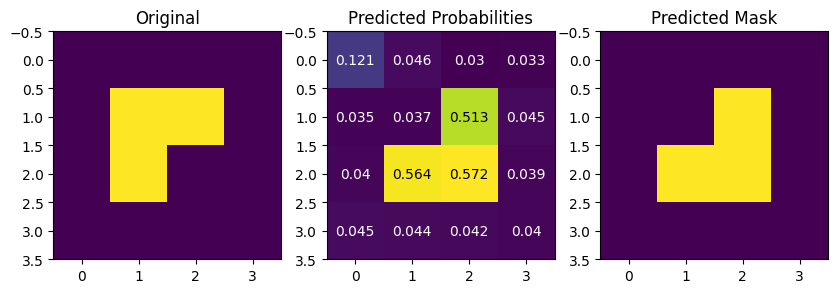

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [25]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

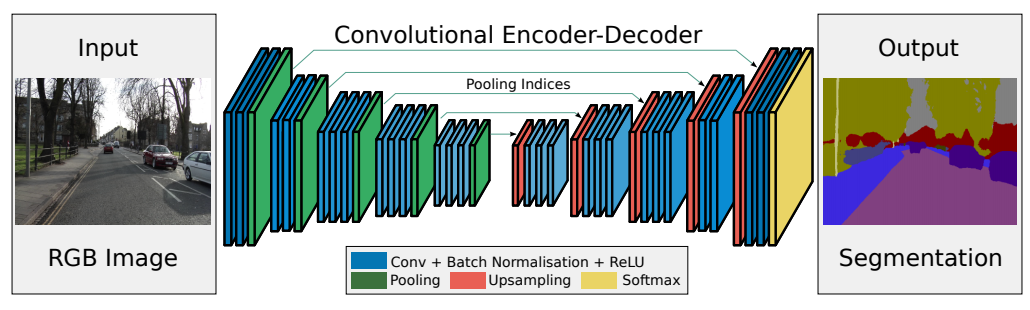

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [27]:
# model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)
# model_vgg16

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [28]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, 
                                     out_channels = out_channels, 
                                     kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))        
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, 
                                         out_channels = out_channels, 
                                         kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [29]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth,  kernel_size = 3, padding = 1):
        super(DecoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, 
                                     out_channels = out_channels, 
                                     kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            if (out_channels==32) & (i==0):
                self.layers.append(nn.Conv2d(in_channels = out_channels, 
                                         out_channels = 1, 
                                         kernel_size = kernel_size, 
                                         padding = padding))
            else:
                self.layers.append(nn.Conv2d(in_channels = out_channels, 
                                             out_channels = out_channels, 
                                             kernel_size = kernel_size, 
                                             padding = padding))
                self.layers.append(nn.BatchNorm2d(out_channels))
                self.layers.append(nn.ReLU(inplace=True))
            
        self.maxpooling = nn.MaxUnpool2d(kernel_size=2) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x, indices):
        x = self.maxpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [30]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        enc_out = num_features
        self.encoder0 = EncoderBlock(in_channels, enc_out, depth=2)
        self.encoder1 = EncoderBlock(enc_out, enc_out * 2, depth=2)
        enc_out = enc_out * 2
        self.encoder2 = EncoderBlock(enc_out, enc_out * 2, depth=3)
        enc_out = enc_out * 2
        self.encoder3 = EncoderBlock(enc_out, enc_out * 2, depth=3)
        enc_out = enc_out * 2
        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(enc_out, enc_out, depth=3)

        # Decoder bottleneck
        # TODO
        self.decoder4 = DecoderBlock(enc_out, enc_out, 3)
        # Decoder
        self.decoder3 = DecoderBlock(enc_out, enc_out //2, 3)
        enc_out = enc_out//2
        self.decoder2 = DecoderBlock(enc_out, enc_out//2, 3)
        enc_out = enc_out//2
        self.decoder1 = DecoderBlock(enc_out, enc_out// 2, 2) 
        enc_out = enc_out//2
        self.decoder0 = DecoderBlock(enc_out, enc_out// 2, 2)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)
        # TODO
        output = self.decoder4(x, indices4)
        output = self.decoder3(output, indices3)
        output = self.decoder2(output, indices2)
        output = self.decoder1(output, indices1)
        output = self.decoder0(output, indices0)
        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

размеры тензора после каждого слоя:
* torch.Size([1, 3, 256, 256])
* torch.Size([1, 64, 128, 128])
* torch.Size([1, 128, 64, 64])
* torch.Size([1, 256, 32, 32])
* torch.Size([1, 512, 16, 16])
* torch.Size([1, 512, 8, 8])
* torch.Size([1, 512, 16, 16])
* torch.Size([1, 256, 32, 32])
* torch.Size([1, 128, 64, 64])
* torch.Size([1, 64, 128, 128])
* torch.Size([1, 1, 256, 256])

In [37]:
! rm -rf models
! mkdir models

In [38]:
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)

criterion = nn.BCEWithLogitsLoss(reduction='sum')
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=9e-1,
    patience=3,  
)

In [39]:
sum([p.numel() for p in model.parameters()])

24888001

In [40]:
from tqdm.notebook import tqdm
from torchmetrics import JaccardIndex

iou = JaccardIndex(threshold=0.5, task="binary", average='none').to('cpu')

In [41]:
def train(model, optimizer, criterion, scheduler, train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_segnet_epoch_'):
    device='cuda'
    model.to(device)
    sigmoid = torch.nn.Sigmoid()
    best_epoch_iou=0
    train_loss, eval_loss, lr_hist, ious = [], [], [], []
    for epoch in range(N_EPOCHS):
        model.train()
        epoch_train_loss = []
        for X, y in train_dataloader:
            optimizer.zero_grad()
            preds = model(X.to(device))
            loss = criterion(preds, y.to(device))
            epoch_train_loss.append(loss.cpu().item())        
            loss.backward()
            optimizer.step()
            
        model.eval()
        eval_epoch_loss, eval_epoch_iou = [], []
        with torch.no_grad():
            for X, y in valid_dataloader:
                preds = model(X.to(device))
                loss = criterion(preds, y.to(device))
                iou_score = iou( sigmoid(preds).cpu(), y.cpu())
                eval_epoch_loss.append(loss.cpu().item())
                eval_epoch_iou.append(iou_score.cpu().item())
        metrics = np.mean(eval_epoch_iou) 
        if metrics>best_epoch_iou:
            best_epoch_iou = metrics
            torch.save(model.state_dict(), f'{SAVE_PATH}{epoch}.pth')
        scheduler.step(metrics)
        train_loss.append(epoch_train_loss) 
        eval_loss.append(eval_epoch_loss)
        ious.append(eval_epoch_iou)
        lr_hist.append(optimizer.param_groups[0]['lr'])
    return model, train_loss, eval_loss, ious, lr_hist

In [42]:
%%time
model, train_loss, eval_loss, ious, lr_hist = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30)

CPU times: user 1min 30s, sys: 2min 37s, total: 4min 7s
Wall time: 3min 12s


Text(0.5, 1.0, 'IoU on eval set. Best: 0.807')

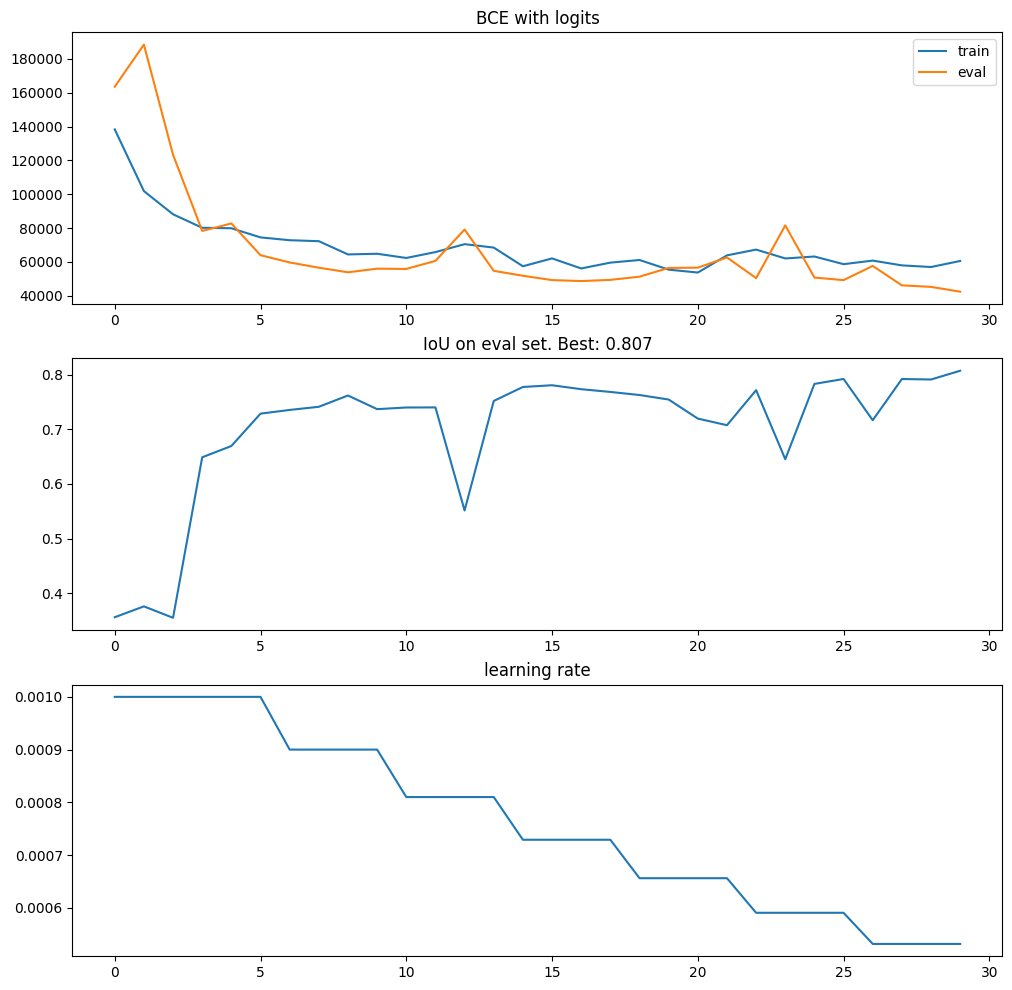

In [43]:
fig, ax = plt.subplots(3,1, figsize=(12, 12))
ax[0].plot([np.mean(p) for p in train_loss], label='train')
ax[0].plot([np.mean(p) for p in eval_loss], label='eval')
ax[0].legend()
ax[0].set_title('BCE with logits')
ax[2].plot(lr_hist, label='lr')
ax[2].set_title('learning rate')
ax[1].plot([np.mean(p) for p in ious], label='iou')
ax[1].set_title(f'IoU on eval set. Best: {np.max([np.mean(p) for p in ious]):.3f}')

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [44]:
! ls models/ -t

best_segnet_epoch_29.pth  best_segnet_epoch_8.pth  best_segnet_epoch_3.pth
best_segnet_epoch_25.pth  best_segnet_epoch_7.pth  best_segnet_epoch_1.pth
best_segnet_epoch_24.pth  best_segnet_epoch_6.pth  best_segnet_epoch_0.pth
best_segnet_epoch_15.pth  best_segnet_epoch_5.pth
best_segnet_epoch_14.pth  best_segnet_epoch_4.pth


In [45]:
def test_results(model, test_dataloader):
    model.to('cpu')
    model.eval()
    preds_list, y_list, x_list = [], [], []
    ious = []
    with torch.no_grad():
        for X, y in tqdm(test_dataloader):
            preds = model(X)
            iou_score = iou(torch.sigmoid(preds).cpu(), y.cpu())
            ious.append(iou_score.cpu().item())
            preds_list.extend(preds.cpu())
            x_list.extend(X.cpu())
            y_list.extend(y)
    return preds_list, y_list, x_list, ious

In [46]:
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_segnet_epoch_29.pth'))

<All keys matched successfully>

In [47]:
%%time
preds_list, y_list, x_list, ious = test_results(model, test_dataloader)

  0%|          | 0/25 [00:00<?, ?it/s]

CPU times: user 1min, sys: 10.5 s, total: 1min 10s
Wall time: 8.9 s


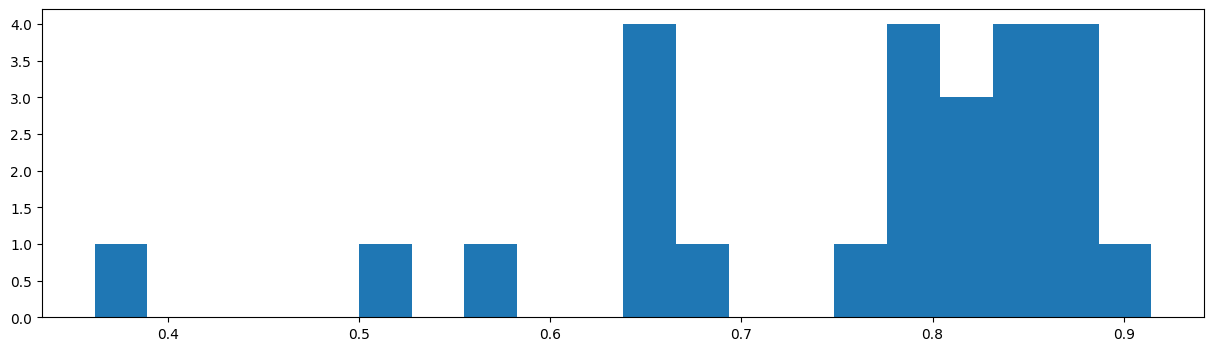

In [48]:
plt.hist(ious, bins=20);

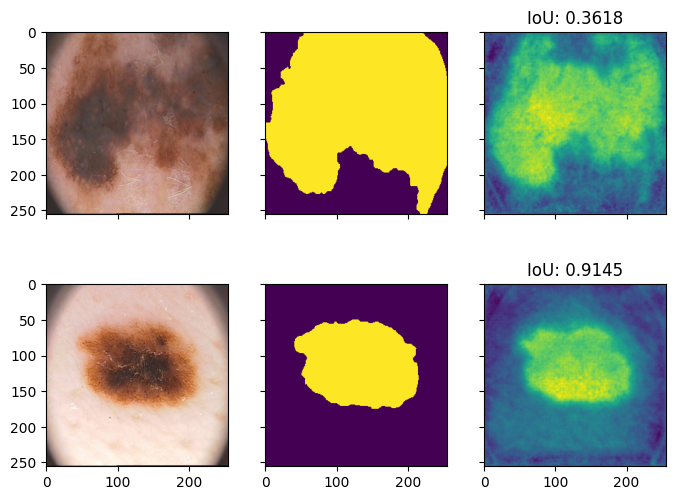

In [49]:
worst_id = np.argmin(ious)
best_id = np.argmax(ious)
fig, ax = plt.subplots(2, 3, figsize=(8,6), sharex=True, sharey=True)

ax[0,0].imshow(x_list[worst_id].permute(1, 2,0))
ax[0,1].imshow(y_list[worst_id].permute(1, 2,0))
ax[0,2].imshow(preds_list[worst_id].permute(1, 2,0))
ax[0,2].set_title(f'IoU: {ious[worst_id]:.4f}');

ax[1,0].imshow(x_list[best_id].permute(1, 2,0))
ax[1,1].imshow(y_list[best_id].permute(1, 2,0))
ax[1,2].imshow(preds_list[best_id].permute(1, 2,0))
ax[1,2].set_title(f'IoU: {ious[best_id]:.4f}');

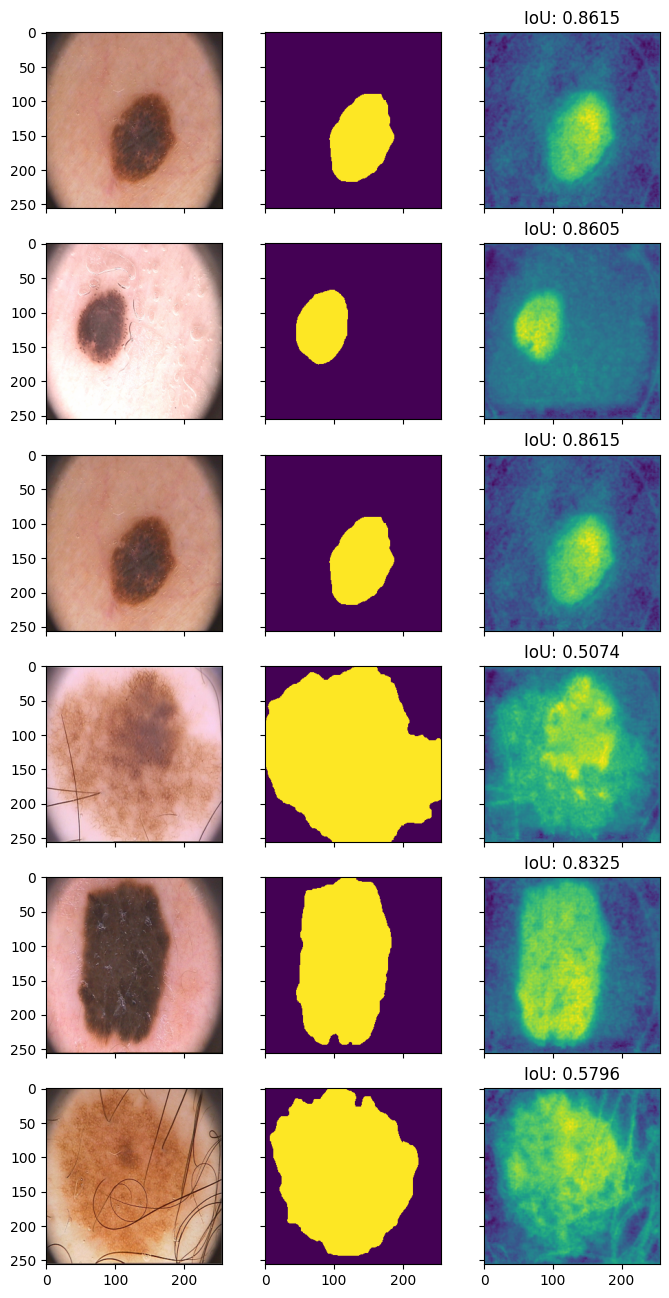

In [50]:
fig, ax = plt.subplots(6, 3, figsize=(8,16), sharex=True, sharey=True)
idxs = np.random.choice(len(test_dataloader), 6)
for i in range(6):
    ax[i,0].imshow(x_list[idxs[i]].permute(1, 2,0))
    ax[i,1].imshow(y_list[idxs[i]].permute(1, 2,0))
    ax[i,2].imshow(preds_list[idxs[i]].permute(1, 2,0))
    ax[i,2].set_title(f'IoU: {ious[idxs[i]]:.4f}');

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [51]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    # TODO
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(logits)
    mask = (probs>threshold)*1.0
    TP = torch.sum((mask==1) & (labels==1))
    FP = torch.sum((mask==1) & (labels==0))
    FN = torch.sum((mask==0) & (labels==1))
    eps = 1e-8
    score = (2*TP+eps) / (2*TP + FN + FP + eps)
    return score

Проверим на корректность функцию dice_score:

In [52]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

/home/juliya/venvs/dls_cv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.3158, device='cuda:0')

тут явно как-то по другому dice в библиотеке  считается...

In [53]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

AssertionError: 

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [54]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):

    '''
    Это лосс.
    '''
    # TODO
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(logits)
    nom = torch.sum(2 * probs * labels)
    denom = torch.sum(probs + labels)
    eps = 1e-8
    loss = 1 - (nom+eps) / (denom + eps)
    return loss

Проверка на корректность:

In [55]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [56]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [57]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [58]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    y_pred_sigm =  torch.sigmoid(y_pred)
    p_t = y_pred_sigm * y_real + (1 - y_pred_sigm) * (1 - y_real)
    bceloss = (y_pred - (y_real * y_pred) + torch.log(1 + torch.exp(-y_pred)))
    return (bceloss * ((1 - p_t) ** gamma)).sum()


Проверка корректности функции:

In [59]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [60]:
focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

tensor(3.6161, device='cuda:0')

очень строгий ассерт - заменим на np.allclose

In [61]:
np.allclose(sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum').cpu(),
            focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0).cpu()
           )

True

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

тут парень все еще 3 года назад сделал https://github.com/i-l-sokolov/Melanoma_segmentation-PyTorch_UNet_SegNet

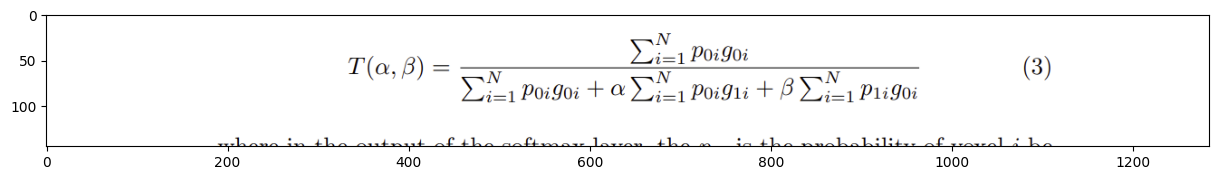

In [62]:
img = Image.open('../images/tversky_loss_formula.png')
plt.imshow(img)

* p - prediction, g - groundtruth
* α - штраф за FP, β - штраф за FN, оба коэффициента принимают значения от  0 and 1, и их сумма равна 1.

In [63]:
def tversky_loss(y_pred : torch.Tensor, y_true : torch.Tensor, alpha=0.5):
    TP = (y_pred*y_true).sum()
    FN = (y_true*(1-y_pred)).sum()
    FP = ((1-y_true)*y_pred).sum()
    return -TP / (TP + alpha*FN + (1-alpha)*FP + 1e-8)


## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [64]:
import gc

In [65]:
torch.cuda.empty_cache()
gc.collect()

26

In [66]:
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)

criterion = DiceLoss(mode='binary')
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=9e-1,
    patience=3,  
)
model.to(device);

In [67]:
%%time
model_dice, train_loss_dice, eval_loss_dice, ious_dice, lr_hist_dice = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_segnet_dice_epoch_')

CPU times: user 1min 33s, sys: 2min 36s, total: 4min 9s
Wall time: 3min 13s


In [68]:
torch.cuda.empty_cache()
gc.collect()

36

In [69]:
def FocalLoss(alpha=-1, gamma=2, reduction='sum'):
    def focal_loss(y_pred, y_true, alpha=alpha, gamma=gamma, reduction=reduction):
        return  sigmoid_focal_loss(y_pred, y_true, alpha=alpha, gamma=gamma, reduction=reduction)
    return focal_loss

In [70]:
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)

criterion = FocalLoss(alpha=-1, gamma=2, reduction='sum')
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=9e-1,
    patience=3,  
)
model.to(device);

In [71]:
%%time
model_focal, train_loss_focal, eval_loss_focal, ious_focal, lr_hist_focal = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_segnet_focal_epoch_')

CPU times: user 1min 31s, sys: 2min 37s, total: 4min 9s
Wall time: 3min 13s


In [72]:
torch.cuda.empty_cache()
gc.collect()

45

In [73]:
def tversky_loss(alpha=0.5):
    def tversky_inner(y_pred : torch.Tensor, y_true : torch.Tensor, alpha=alpha):
        TP = (y_pred*y_true).sum()
        FN = (y_true*(1-y_pred)).sum()
        FP = ((1-y_true)*y_pred).sum()
        return 1 - (TP + 1e-8) / (TP + alpha*FN + (1-alpha)*FP + 1e-8)
    return tversky_inner

In [74]:
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)

criterion = tversky_loss(alpha=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=9e-1,
    patience=3,  
)
model.to(device);

In [75]:
%%time
model_ta03, train_loss_ta03, eval_loss_ta03, ious_ta03, lr_hist_ta03 = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_segnet_tversky_epoch_')

CPU times: user 1min 31s, sys: 2min 36s, total: 4min 8s
Wall time: 3min 12s


Text(0.5, 1.0, 'IoU ')

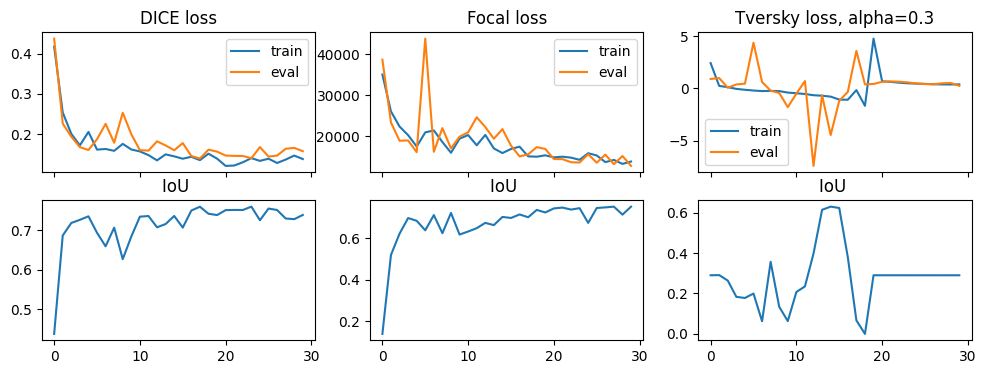

In [76]:
fig, ax = plt.subplots(2, 3, figsize=(12, 4), sharex=True)
ax[0,0].plot([np.mean(p) for p in train_loss_dice], label='train')
ax[0,0].plot([np.mean(p) for p in eval_loss_dice], label='eval')
ax[0,0].legend()
ax[0,0].set_title('DICE loss')
ax[0,1].plot([np.mean(p) for p in train_loss_focal], label='train')
ax[0,1].plot([np.mean(p) for p in eval_loss_focal], label='eval')
ax[0,1].legend()
ax[0,1].set_title('Focal loss')
ax[0,2].plot([np.mean(p) for p in train_loss_ta03], label='train')
ax[0,2].plot([np.mean(p) for p in eval_loss_ta03], label='eval')
ax[0,2].legend()
ax[0,2].set_title('Tversky loss, alpha=0.3')
ax[1,0].plot([np.mean(p) for p in ious_dice], label='iou')
ax[1,0].set_title('IoU ')
ax[1,1].plot([np.mean(p) for p in ious_focal], label='iou')
ax[1,1].set_title('IoU ')
ax[1,2].plot([np.mean(p) for p in ious_ta03], label='iou')
ax[1,2].set_title('IoU ')

In [79]:
!ls models/ -t

best_segnet_tversky_epoch_14.pth  best_segnet_dice_epoch_23.pth
best_segnet_focal_epoch_27.pth	  best_segnet_epoch_29.pth


 С dice лучшее качетво было на 23 эпохе, с focal - на 27, bce - можно продолжать обучение. Тверский лосс нельзя просто взять и начать использовать - ничего не работает). Возможно стоило взять уже неплохой чекпойнт, выбрать за кого наказывать сильнее, подобрать альфу, и делать все это при маленьком learning rate

In [80]:
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_segnet_focal_epoch_27.pth'))
_, _, _, f_ious = test_results(model, test_dataloader)
print(f'Mean Focal IoU: {np.mean(f_ious)}')
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_segnet_dice_epoch_23.pth'))
_, _, _, d_ious = test_results(model, test_dataloader)
print(f'Mean Dice IoU: {np.mean(d_ious)}')
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_segnet_epoch_29.pth'))
_, _, _, b_ious = test_results(model, test_dataloader)
print(f'Mean BCE IoU: {np.mean(b_ious)}')  
model = SegNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_segnet_tversky_epoch_14.pth'))
_, _, _, t_ious = test_results(model, test_dataloader)
print(f'Mean Tversky Tversky: {np.mean(t_ious)}') 

  0%|          | 0/25 [00:00<?, ?it/s]

Mean Focal IoU: 0.7235288834571838


  0%|          | 0/25 [00:00<?, ?it/s]

Mean Dice IoU: 0.7287744998931884


  0%|          | 0/25 [00:00<?, ?it/s]

Mean BCE IoU: 0.7557092845439911


  0%|          | 0/25 [00:00<?, ?it/s]

Mean Tversky Tversky: 0.5656798857450486


# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

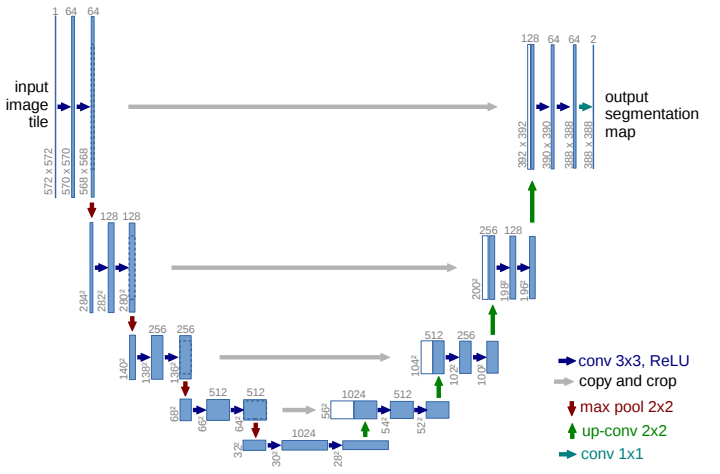

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [81]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

Для энкодера возьмем реализованный класс Segnet, будем везде брать глубину 1. Декодер будет такой:
1)  X_previous апсемплится до размеров X_previous_1, кол-во каналов в 2 раза уменьшается (ConvTransposed2d)
2)  складывается X_previous_upsampled и X_previous_1 (по размерности каналов)
3)  кол-во каналов уменьшается в 2 раза  (conv2d)
4)  ReLU + BatchNorm

In [82]:
class DecoderBlockUnet(nn.Module):
    def __init__(self, in_channels_trans, out_channels_trans, in_channels_conv, out_channels_conv ):
        super(DecoderBlockUnet, self).__init__() # инициируем экземляр класса, наследующего от n
        self.upsample = nn.ConvTranspose2d(in_channels_trans, out_channels_trans, kernel_size=2, stride=2)
        self.conv = nn.Conv2d(in_channels_conv, out_channels_conv, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(out_channels_conv)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x, x_previous):
        x = self.relu(self.upsample(x))
        x = torch.cat([x, x_previous], dim=1)
        x = self.relu(self.bn(self.conv(x)))
        return x

In [83]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:           
        super(UNet, self).__init__()
        # Encoder
        enc_out = num_features
        self.encoder0 = EncoderBlock(enc_out, enc_out, depth=1)
        self.conv2d = nn.Conv2d(3, enc_out, kernel_size=3, padding=1)
        self.encoder1 = EncoderBlock(enc_out, enc_out * 2, depth=1)
        enc_out = enc_out * 2
        self.encoder2 = EncoderBlock(enc_out, enc_out * 2, depth=1)
        enc_out = enc_out * 2
        self.encoder3 = EncoderBlock(enc_out, enc_out * 2, depth=1)
        enc_out = enc_out * 2
        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder_bottleneck = EncoderBlock(enc_out, enc_out * 2, depth=1)
        enc_out = enc_out * 2
        # Decoder bottleneck
        # TODO
        self.decoder4 = DecoderBlockUnet(enc_out, enc_out // 2, enc_out, enc_out // 2)
        enc_out = enc_out // 2
        self.decoder3 = DecoderBlockUnet(enc_out, enc_out //2, enc_out, enc_out // 2)
        enc_out = enc_out//2
        self.decoder2 = DecoderBlockUnet(enc_out, enc_out//2, enc_out, enc_out // 2)
        enc_out = enc_out//2
        self.decoder1 = DecoderBlockUnet(enc_out, enc_out// 2, enc_out, enc_out // 2) 
        enc_out = enc_out//2
        self.conv2dout = nn.Conv2d(enc_out, 1, kernel_size=1)

    def forward(self, x):
        # encoder
        x0 = self.conv2d(x)
        x1, _ = self.encoder1(x0)
        x2, _ = self.encoder2(x1)
        x3, _ = self.encoder3(x2)
        x4, _ = self.encoder_bottleneck(x3)
        # TODO
        output = self.decoder4(x4, x3)
        output = self.decoder3(output, x2)
        output = self.decoder2(output, x1)
        output = self.decoder1(output, x0)
        output = self.conv2dout(output)
        return output 
        


* torch.Size([1, 3, 256, 256])
* torch.Size([1, 64, 256, 256])
* torch.Size([1, 128, 128, 128])
* torch.Size([1, 256, 64, 64])
* torch.Size([1, 512, 32, 32])
* torch.Size([1, 1024, 16, 16])
* torch.Size([1, 512, 32, 32])
* torch.Size([1, 256, 64, 64])
* torch.Size([1, 128, 128, 128])
* torch.Size([1, 64, 256, 256])
* torch.Size([1, 1, 256, 256])

In [84]:
unet_model = UNet()

In [85]:
sum([p.numel() for p in unet_model.parameters()])

15367553

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



Вообще говоря, значения метрик очень сильно зависят от сида. Тут чуть лучше оказалась Юнет - у нее на треть меньше параметров, соответсвенно она занимает меньше места. По времени Юнет учится дольше

Юнет оказалась чуть лучше с метриками DICE и Focal по сравнению с Segnet (0.74 vs 0.72), а вот с ВСЕ одинаковый получился результат

In [86]:
torch.cuda.empty_cache()
gc.collect()

46466

In [87]:
model = UNet(in_channels=3, out_channels = 1, num_features = 64)

criterion = DiceLoss(mode='binary')
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=8e-1,
    patience=2,  
)
model.to(device);

In [88]:
%%time
unetmodel_dice, unettrain_loss_dice, uneteval_loss_dice, unetious_dice, unetlr_hist_dice = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_unet_dice_epoch_')

CPU times: user 1min 34s, sys: 3min 14s, total: 4min 49s
Wall time: 3min 53s


Text(0.5, 1.0, 'IoU on eval set. Best: 0.785')

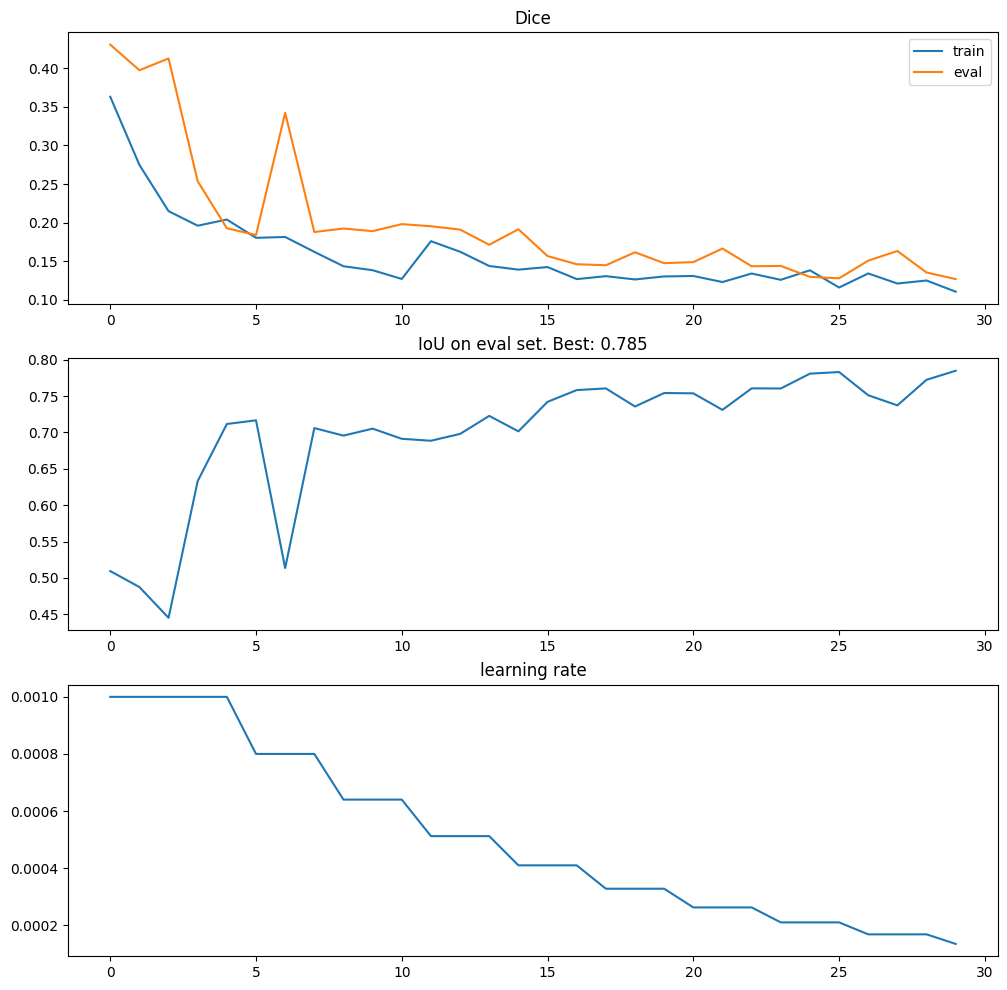

In [89]:
fig, ax = plt.subplots(3,1, figsize=(12, 12))
ax[0].plot([np.mean(p) for p in unettrain_loss_dice], label='train')
ax[0].plot([np.mean(p) for p in uneteval_loss_dice], label='eval')
ax[0].legend()
ax[0].set_title('Dice')
ax[2].plot(unetlr_hist_dice, label='lr')
ax[2].set_title('learning rate')
ax[1].plot([np.mean(p) for p in unetious_dice], label='iou')
ax[1].set_title(f'IoU on eval set. Best: {np.max([np.mean(p) for p in unetious_dice]):.3f}')

In [90]:
model = UNet(in_channels=3, out_channels = 1, num_features = 64)

criterion = FocalLoss(alpha=-1, gamma=2, reduction='sum')
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=8e-1,
    patience=2,  
)
model.to(device);

In [91]:
%%time
unetmodel_focal, unettrain_loss_focal, uneteval_loss_focal, unetious_focal, unetlr_hist_focal = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_unet_focal_epoch_')

CPU times: user 1min 35s, sys: 3min 15s, total: 4min 51s
Wall time: 3min 54s


Text(0.5, 1.0, 'IoU on eval set. Best: 0.796')

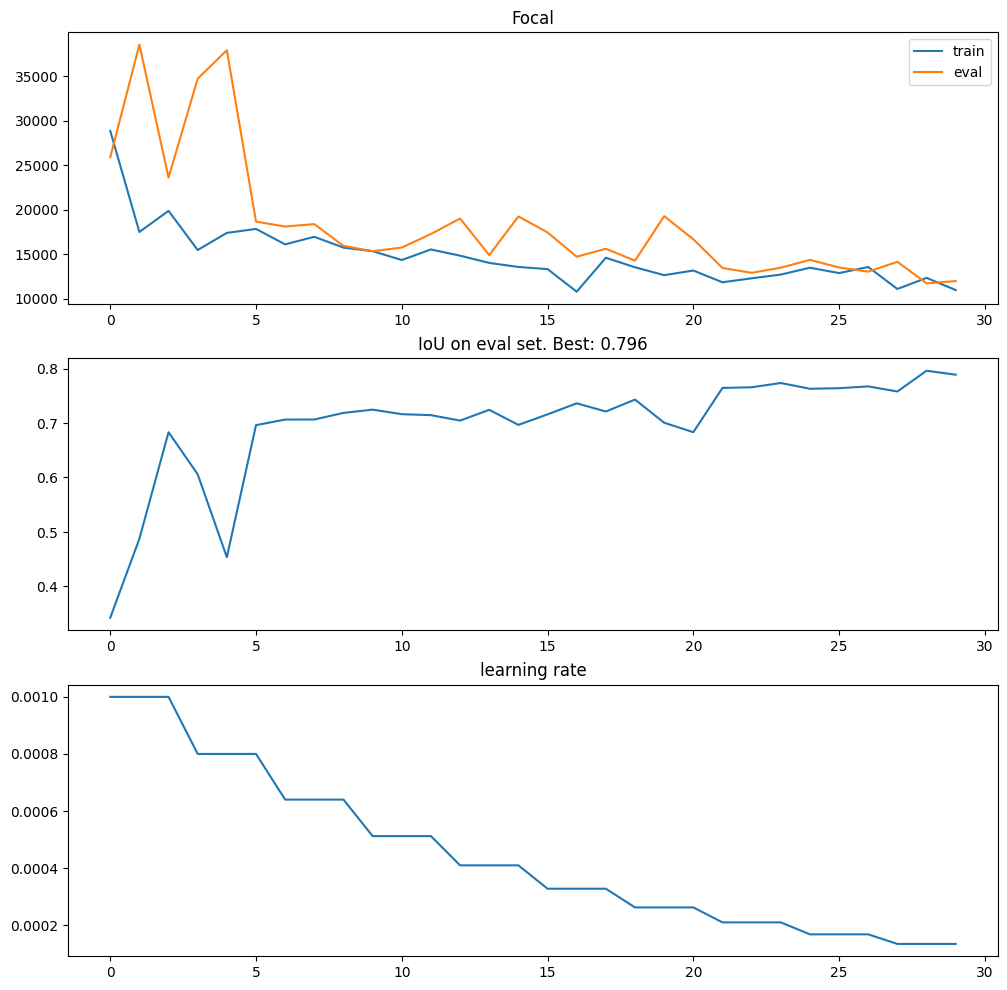

In [92]:
fig, ax = plt.subplots(3,1, figsize=(12, 12))
ax[0].plot([np.mean(p) for p in unettrain_loss_focal], label='train')
ax[0].plot([np.mean(p) for p in uneteval_loss_focal], label='eval')
ax[0].legend()
ax[0].set_title('Focal')
ax[2].plot(unetlr_hist_focal, label='lr')
ax[2].set_title('learning rate')
ax[1].plot([np.mean(p) for p in unetious_focal], label='iou')
ax[1].set_title(f'IoU on eval set. Best: {np.max([np.mean(p) for p in unetious_focal]):.3f}')

In [93]:
import gc
torch.cuda.empty_cache()
gc.collect()



59

In [94]:
# model = UNet(in_channels=3, out_channels = 1, num_features = 64)
model = UNet()
criterion = nn.BCEWithLogitsLoss(reduction='sum')
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=8e-1,
    patience=2,  
)
model.to(device);

In [95]:
%%time
unetmodel_bce, unettrain_loss_bce, uneteval_loss_bce, unetious_bce, unetlr_hist_bce = train(model, optimizer, criterion, scheduler, 
                                                    train_dataloader, valid_dataloader, iou,  N_EPOCHS=30, SAVE_PATH='models/best_unet_bce_epoch_')

CPU times: user 1min 35s, sys: 3min 16s, total: 4min 51s
Wall time: 3min 54s


Text(0.5, 1.0, 'IoU on eval set. Best: 0.782')

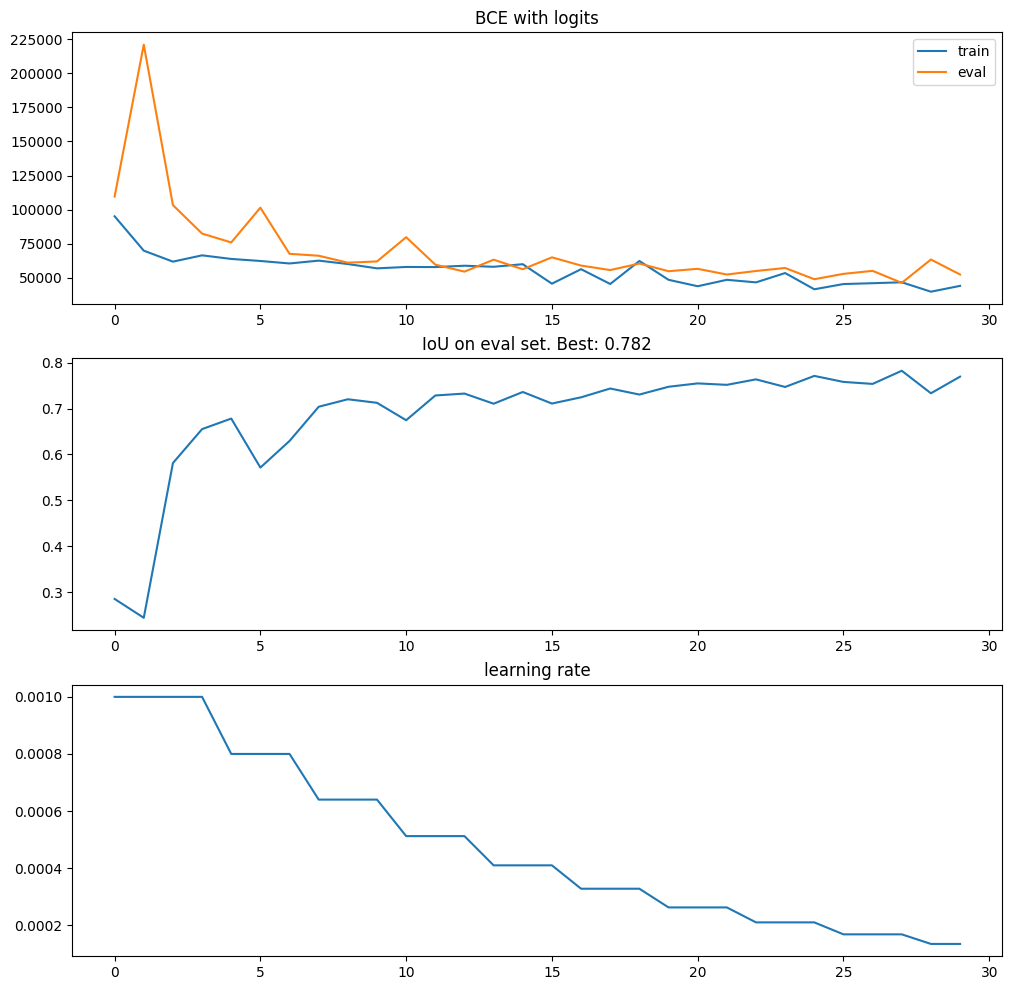

In [96]:
fig, ax = plt.subplots(3,1, figsize=(12, 12))
ax[0].plot([np.mean(p) for p in unettrain_loss_bce], label='train')
ax[0].plot([np.mean(p) for p in uneteval_loss_bce], label='eval')
ax[0].legend()
ax[0].set_title('BCE with logits')
ax[2].plot(unetlr_hist_bce, label='lr')
ax[2].set_title('learning rate')
ax[1].plot([np.mean(p) for p in unetious_bce], label='iou')
ax[1].set_title(f'IoU on eval set. Best: {np.max([np.mean(p) for p in unetious_bce]):.3f}')

In [97]:
model = UNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_unet_focal_epoch_28.pth'))
_, _, _, f_ious = test_results(model, test_dataloader)
print(f'Mean Focal IoU: {np.mean(f_ious)}')
model = UNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_unet_dice_epoch_29.pth'))
_, _, _, d_ious = test_results(model, test_dataloader)
print(f'Mean Dice IoU: {np.mean(d_ious)}')
model = UNet(in_channels=3, out_channels = 1, num_features = 64)
model.load_state_dict(torch.load('models/best_unet_bce_epoch_27.pth'))
_, _, _, b_ious = test_results(model, test_dataloader)
print(f'Mean BCE IoU: {np.mean(b_ious)}')  


  0%|          | 0/25 [00:00<?, ?it/s]

Mean Focal IoU: 0.7438159215450287


  0%|          | 0/25 [00:00<?, ?it/s]

Mean Dice IoU: 0.7419055259227753


  0%|          | 0/25 [00:00<?, ?it/s]

Mean BCE IoU: 0.7541342937946319
